

# Vehicle Classification


**Problem definition:**
The [vehicle-classiciation](https://www.kaggle.com/datasets/mohamedmaher5/vehicle-classification/data)
folder contains images of vehicle, classified into 7 categories: Auto Rickshaws, Bikes, Cars, Motorcycles, Planes, Ships, or Trains.

The dataset can be utilized to develop a machine learning model that can predict whether an image contains a vehicle of the aforementioned categories or not.

## Dataset folders

* Auto Rickshaws aka. Tuk-tuk (800 images)
* Bikes (800 images)
* Cars (790 images)
* Motorcycles (800 images)
* Planes (800 images)
* Ships (800 images)
* Trains (800 images)



## Vision & Mission

**Vision:** To provide an accurate and accessible image classification tool for various vehicle types, suitable for diverse applications.

**Mission:** To develop and deploy a robust image classification model capable of accurately identifying and categorizing various vehicle types, providing a foundation for automated vehicle recognition systems.

## Data gathering

Source of data: https://www.kaggle.com/datasets/mohamedmaher5/vehicle-classification/data

In [12]:
#@title Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import OrderedDict
import cv2
from PIL import Image
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator



from tensorflow.keras import Sequential
from keras.layers import *

In [2]:
#@title Define data path

import kagglehub

path = kagglehub.dataset_download("mohamedmaher5/vehicle-classification")

Using Colab cache for faster access to the 'vehicle-classification' dataset.


In [3]:
print(path)

/kaggle/input/vehicle-classification


In [4]:
print("Contents of the downloaded dataset directory:")
for item in os.listdir(path):
    print(f"- {item}")

# Also print contents of the first level subdirectories if any, to find 'Vehicles'
for item in os.listdir(path):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        print(f"\nContents of {item_path}:")
        for sub_item in os.listdir(item_path):
            print(f"  - {sub_item}")

Contents of the downloaded dataset directory:
- Vehicles

Contents of /kaggle/input/vehicle-classification/Vehicles:
  - Ships
  - Cars
  - Motorcycles
  - Bikes
  - Trains
  - Auto Rickshaws
  - Planes


## EDA
* How many images do we have?
* How many images do we have per class?
* Is there a very unbalanced class?

Visualize the dataset, using  the matplotlib library to display a random subset of images for the different classes.

In [5]:
# The downloaded dataset is extracted into a 'path', and the actual categories
# are nested within a 'Vehicles' subfolder inside that path.
base_image_path = os.path.join(path, 'Vehicles')

# Get the list of categories (folder names)
categories = os.listdir(base_image_path)

# Create a dictionary to store the count of images per category
category_counts = {}
for category in categories:
    category_path = os.path.join(base_image_path, category)
    if os.path.isdir(category_path):
        category_counts[category] = len(os.listdir(category_path))

# Display the results
print("Number of images per category:")
for category, count in category_counts.items():
    print(f"- {category}: {count} images")

# Total # of images
total = 0
for category, count in category_counts.items():
  total += count
print(f"Total no. of images: {total}")

Number of images per category:
- Ships: 800 images
- Cars: 790 images
- Motorcycles: 800 images
- Bikes: 800 images
- Trains: 800 images
- Auto Rickshaws: 800 images
- Planes: 800 images
Total no. of images: 5590


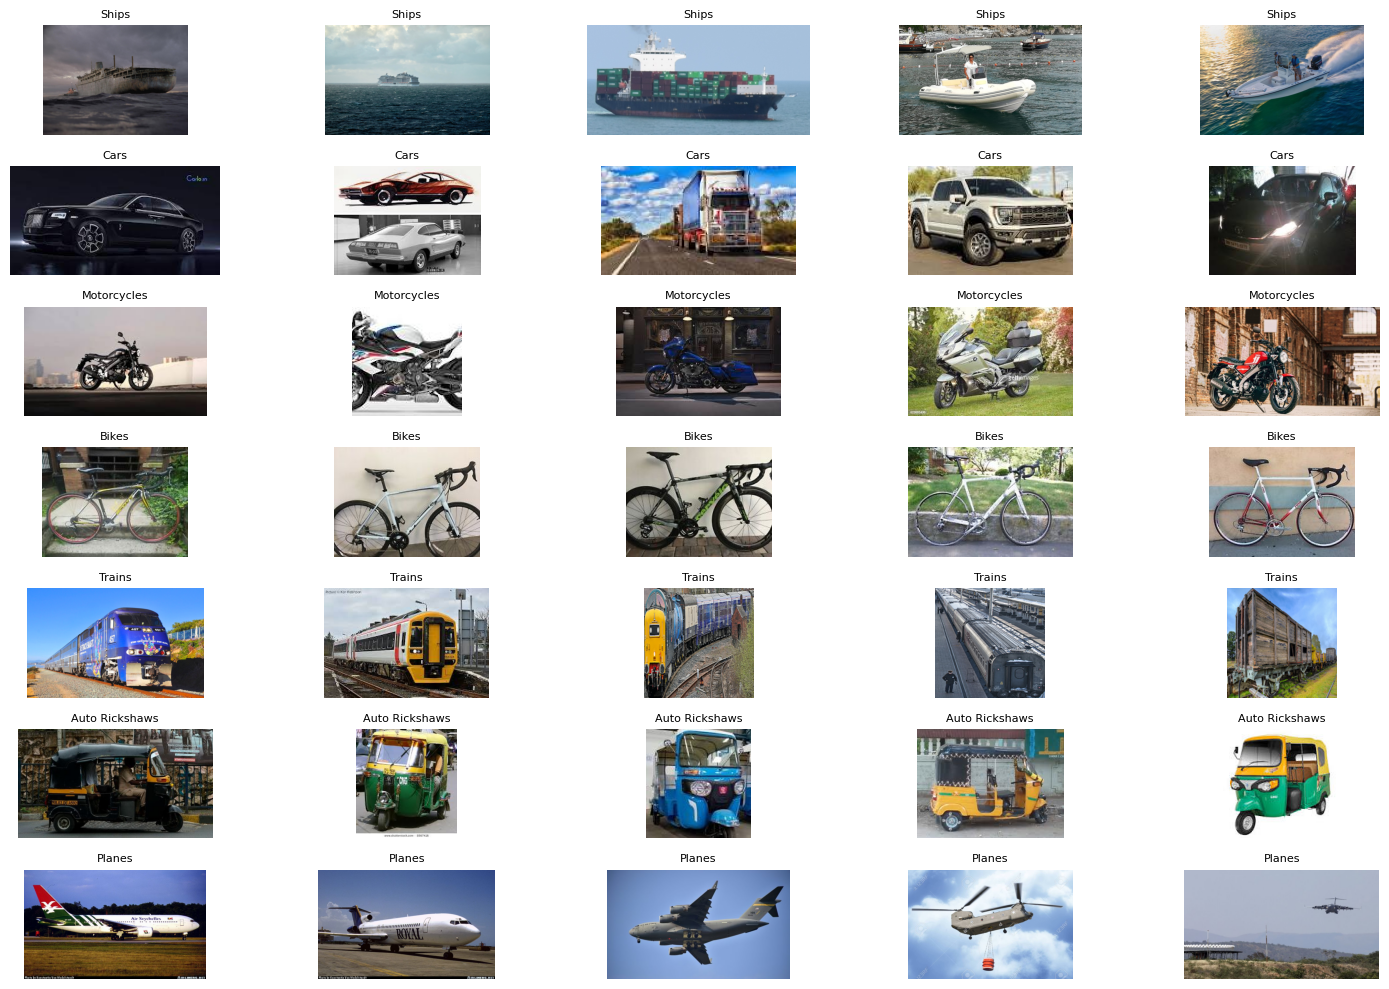

In [6]:
# Visualize a random subset of images for each class
plt.figure(figsize=(15, 10))
num_images_to_display = 5 # Number of random images to display per category

for i, category in enumerate(categories):
    category_path = os.path.join(base_image_path, category)
    image_files = os.listdir(category_path)

    # Select a random subset of images
    selected_images = np.random.choice(image_files, min(num_images_to_display, len(image_files)), replace=False)

    for j, image_file in enumerate(selected_images):
        image_path = os.path.join(category_path, image_file)
        img = Image.open(image_path)

        plt.subplot(len(categories), num_images_to_display, i * num_images_to_display + j + 1)
        plt.imshow(img)
        plt.title(f"{category}", fontsize=8)
        plt.axis('off')

plt.tight_layout()
plt.show()


Image dimension summary per category:

Category: Ships
             width       height
count   800.000000   800.000000
mean   1588.168750  1046.348750
std    1058.082524   737.786994
min     332.000000   260.000000
25%     965.500000   626.500000
50%    1200.000000   810.000000
75%    1920.000000  1200.000000
max    7993.000000  5995.000000

Category: Cars
             width       height
count   790.000000   790.000000
mean    230.348101   154.277215
std      97.115543    65.302807
min      92.000000    40.000000
25%     162.000000   108.000000
50%     259.000000   168.000000
75%     284.750000   183.000000
max    1920.000000  1440.000000

Category: Motorcycles
             width      height
count   800.000000   800.00000
mean    296.070000   208.75875
std     198.037285   138.64463
min     100.000000    81.00000
25%     258.000000   168.00000
50%     275.000000   183.00000
75%     299.000000   194.00000
max    1920.000000  1689.00000

Category: Bikes
            width     height
coun

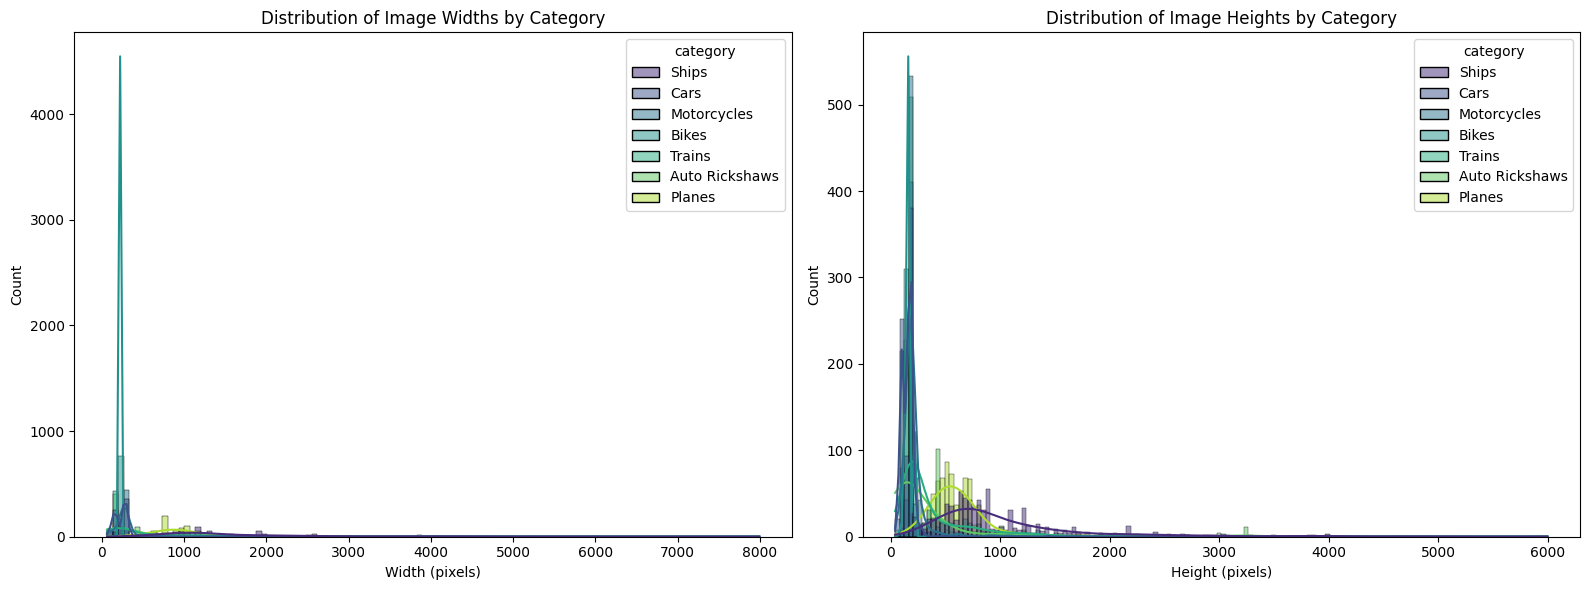

In [7]:
#@title Image Dimension Consistency
image_dimensions = []

for category in categories:
    category_path = os.path.join(base_image_path, category)
    image_files = os.listdir(category_path)

    for image_file in image_files:
        try:
            image_path = os.path.join(category_path, image_file)
            with Image.open(image_path) as img:
                image_dimensions.append({'category': category, 'width': img.size[0], 'height': img.size[1]})
        except Exception as e:
            print(f"Error processing image {image_file} in {category}: {e}")

dimensions_df = pd.DataFrame(image_dimensions)

print("\nImage dimension summary per category:")
for category in categories:
    category_df = dimensions_df[dimensions_df['category'] == category]
    if not category_df.empty:
        print(f"\nCategory: {category}")
        print(category_df[['width', 'height']].describe())
    else:
        print(f"\nNo dimension data for category: {category}")


# Visualize the distribution of dimensions
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=dimensions_df, x='width', hue='category', kde=True, palette='viridis')
plt.title('Distribution of Image Widths by Category')
plt.xlabel('Width (pixels)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(data=dimensions_df, x='height', hue='category', kde=True, palette='viridis')
plt.title('Distribution of Image Heights by Category')
plt.xlabel('Height (pixels)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Data Preprocessing

In [28]:
train_data = tf.keras.utils.image_dataset_from_directory(
    base_image_path,
    validation_split=0.2,
    subset="training",
    seed=42,                  # Kept identical so splits match perfectly
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'  # Keeps your one-hot encoding active!
)

test_data = tf.keras.utils.image_dataset_from_directory(
    base_image_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32,            # 32 is perfect here for modern validation pipelines
    label_mode='categorical'
)


Found 5588 files belonging to 7 classes.
Using 4471 files for training.
Found 5588 files belonging to 7 classes.
Using 1117 files for validation.


## Model Training & Evaluation
1. CNN model
2. EfficientNET

The CNN model will be much more computationally expensive, especially to avoid overfitting, therefore we will use EfficientNET.

### CNN Model

In [34]:
from tensorflow.keras import backend as K
from tensorflow.keras import layers, models
from keras.callbacks import EarlyStopping

K.clear_session()

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


model = models.Sequential([
    # Step A: Tell the model what shape to expect
    layers.Input(shape=(224, 224, 3)),

    # Step B: Normalize the raw pixels to 0-1 range here on the GPU!
    layers.Rescaling(1./255),

    # Step C: Your safe data augmentations
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),     # Set to 0.05 (~18 deg) so it isn't too extreme
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),


    #convolutional layer
    layers.Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=[224, 224, 3]),
    #pooling layer
    layers.MaxPooling2D(pool_size=(2, 2)),
    #convolutional layer
    layers.Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'),
    #pooling layer
    layers.MaxPooling2D(pool_size=(2, 2)),
    #Add Flatten
    layers.Flatten(),
    #Fully Connected layer
    layers.Dense(128, activation='relu'),
    layers.Dense(7, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the model
model_history=model.fit(train_data, epochs=15, validation_data=test_data, callbacks=[early_stopping])

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 224ms/step - accuracy: 0.1436 - loss: 8.1238 - val_accuracy: 0.1244 - val_loss: 1.9474
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 217ms/step - accuracy: 0.1445 - loss: 1.9466 - val_accuracy: 0.1209 - val_loss: 1.9457
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 46s 255ms/step - accuracy: 0.1440 - loss: 1.9464 - val_accuracy: 0.1423 - val_loss: 1.9439
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 216ms/step - accuracy: 0.1452 - loss: 1.9462 - val_accuracy: 0.1773 - val_loss: 1.9295
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 207ms/step - accuracy: 0.1436 - loss: 1.9460 - val_accuracy: 0.2077 - val_loss: 1.9112
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 41s 211ms/step - accuracy: 0.1391 - loss: 2.0790 - val_accuracy: 0.1620 - val_loss: 1.9467
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 249ms/step - accuracy: 0.1434 - loss: 1.9519 - val_accuracy: 0.1844 - val_loss: 1.9362
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 212ms/step - accuracy: 0.1362 - loss: 1.9464 - val

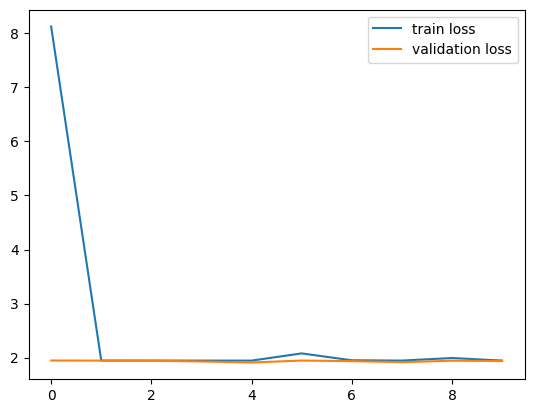

In [35]:
plt.plot(model_history.history['loss'],label='train loss')
plt.plot(model_history.history['val_loss'],label='validation loss')
plt.legend()
plt.show()


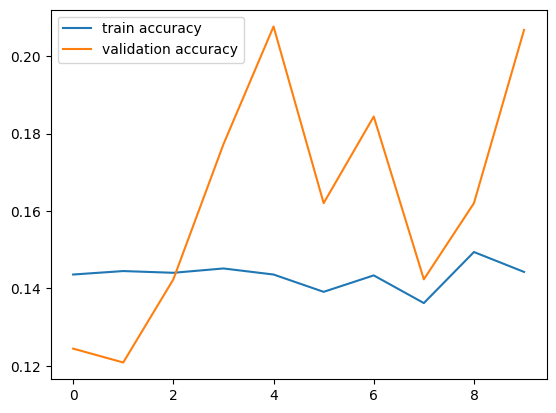

In [36]:
plt.plot(model_history.history['accuracy'],label='train accuracy')
plt.plot(model_history.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.show()


In [18]:
model.evaluate(train_data)

140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 270ms/step - accuracy: 1.0000 - loss: 7.7621e-05


[7.762112363707274e-05, 1.0]

In [19]:
model.evaluate(test_data)

1117/1117 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8129 - loss: 1.2174


[1.2173923254013062, 0.8128916621208191]

### EfficientNet

In [39]:
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.callbacks import EarlyStopping

# 1. Clear any old session states from memory
K.clear_session()

# 2. Setup your training safeguard callback (Extended to 40 epochs with a patience of 5)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# 3. Load the Pre-trained EfficientNetB0 backbone
# We set include_top=False because we don't want Google's 1000-class classifier.
base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# 4. CRUCIAL STEP: Freeze the backbone layers!
# This locks Google's pre-trained vehicle feature detectors so we don't ruin them.
base_model.trainable = False

# 5. Connect the pipeline using the Keras Functional API
inputs = layers.Input(shape=(224, 224, 3))

# Pass raw pixels to your augmentations (NOTE: No Rescaling layer here!)
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomRotation(0.05)(x)
x = layers.RandomBrightness(0.2)(x)
x = layers.RandomContrast(0.2)(x)

# Pass the augmented raw images directly into EfficientNet
x = base_model(x, training=False)

# Convert the 3D feature map into a clean 1D feature vector
x = layers.GlobalAveragePooling2D()(x)

# Add a Dropout layer to prevent your final classification head from overfitting
x = layers.Dropout(0.3)(x)

# Your final classification output layer for your 7 vehicle classes
outputs = layers.Dense(7, activation='softmax')(x)

# Bind inputs and outputs together into your definitive model
model = models.Model(inputs, outputs)

# 6. Compile with a tailored Transfer Learning learning rate
# Pre-trained models need a gentle learning rate (0.0001) so they don't get shocked by bad early gradients.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Visually verify everything looks right
model.summary()

# 7. Start training! (Bumping max epochs to 40 since Early Stopping has your back)
model_history = model.fit(
    train_data,
    epochs=20,
    validation_data=test_data,
    callbacks=[early_stopping]
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 45s 253ms/step - accuracy: 0.5556 - loss: 1.4674 - val_accuracy: 0.9221 - val_loss: 0.9678
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 220ms/step - accuracy: 0.9119 - loss: 0.7702 - val_accuracy: 0.9722 - val_loss: 0.5278
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 257ms/step - accuracy: 0.9517 - loss: 0.4722 - val_accuracy: 0.9839 - val_loss: 0.3361
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 224ms/step - accuracy: 0.9626 - loss: 0.3302 - val_accuracy: 0.9875 - val_loss: 0.2404
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 46s 258ms/step - accuracy: 0.9653 - loss: 0.2537 - val_accuracy: 0.9902 - val_loss: 0.1847
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 228ms/step - accuracy: 0.9725 - loss: 0.2042 - val_accuracy: 0.9902 - val_loss: 0.1496
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 223ms/step - accuracy: 0.9716 - loss: 0.1748 - val_accuracy: 0.9910 - val_loss: 0.1251
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 41s 224ms/step - accuracy: 0.9754 - loss: 0

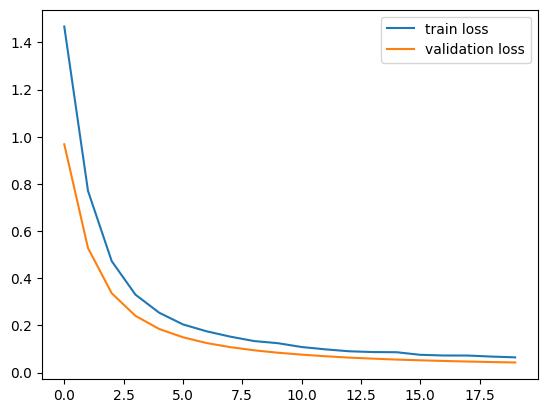

In [40]:
plt.plot(model_history.history['loss'],label='train loss')
plt.plot(model_history.history['val_loss'],label='validation loss')
plt.legend()
plt.show()

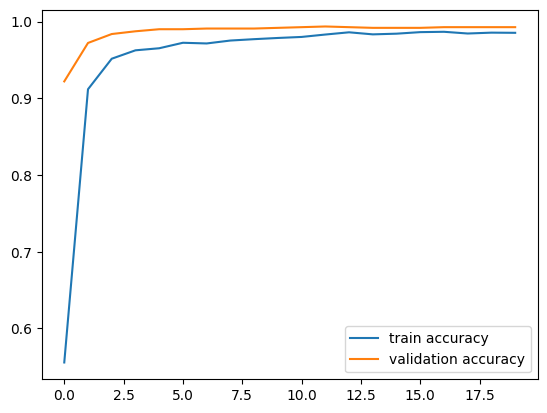

In [41]:
plt.plot(model_history.history['accuracy'],label='train accuracy')
plt.plot(model_history.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.show()

## Adding "Other" class

In [49]:
import os
import shutil
import glob
import kagglehub

# 1. Define our new writable working paths
master_dir = '/kaggle/working/master_dataset'
os.makedirs(master_dir, exist_ok=True)

# 2. Source path for original 7 vehicle classes
vehicle_source = '/kaggle/input/vehicle-classification/Vehicles'

# 3. Copy the 7 original vehicle folders over to our writable directory
print("Copying original 7 vehicle classes...")
for folder_name in os.listdir(vehicle_source):
    src_folder = os.path.join(vehicle_source, folder_name)
    dst_folder = os.path.join(master_dir, folder_name)

    if os.path.isdir(src_folder):
        # Using symlinks or copying — copying ensures data is fully present
        if not os.path.exists(dst_folder):
            shutil.copytree(src_folder, dst_folder)

# 4. Download and locate the non-car images
print("Downloading and processing the 'Other' class...")
noncar_dataset_path = kagglehub.dataset_download("lachlannegus/car-and-non-car-dataset")
noncar_test_source = os.path.join(noncar_dataset_path, 'Car Dataset', 'Test', 'non-car')

# Create the 8th folder called 'Other'
other_dst_folder = os.path.join(master_dir, 'Other')
os.makedirs(other_dst_folder, exist_ok=True)

# Collect all image types from the non-car source directory
valid_extensions = ('*.png', '*.jpg', '*.jpeg', '*.bmp', '*.gif')
noncar_images = []
for ext in valid_extensions:
    noncar_images.extend(glob.glob(os.path.join(noncar_test_source, ext)))

# Copy a balanced sample (e.g., up to 800 images) into the 'Other' folder
max_other_images = 800
for img_path in noncar_images[:max_other_images]:
    shutil.copy(img_path, other_dst_folder)

print("\n--- Directory Setup Complete! ---")
print(f"Master directory established at: {master_dir}")
print(f"Total folders inside master directory: {len(os.listdir(master_dir))}")
print("Classes identified:", os.listdir(master_dir))

Copying original 7 vehicle classes...
Using Colab cache for faster access to the 'car-and-non-car-dataset' dataset.

--- Directory Setup Complete! ---
Master directory established at: /kaggle/working/master_dataset
Total folders inside master directory: 8
Classes identified: ['Other', 'Trains', 'Cars', 'Ships', 'Auto Rickshaws', 'Motorcycles', 'Bikes', 'Planes']


In [52]:
train_data = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/working/master_dataset',
    validation_split=0.2,
    subset="training",
    seed=42,                  # Kept identical so splits match perfectly
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'  # Keeps your one-hot encoding active!
)

test_data = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/working/master_dataset',
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32,            # 32 is perfect here for modern validation pipelines
    label_mode='categorical'
)


Found 6388 files belonging to 8 classes.
Using 5111 files for training.
Found 6388 files belonging to 8 classes.
Using 1277 files for validation.


In [53]:
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.callbacks import EarlyStopping

# 1. Clear any old session states from memory
K.clear_session()

# 2. Setup your training safeguard callback (Extended to 40 epochs with a patience of 5)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# 3. Load the Pre-trained EfficientNetB0 backbone
# We set include_top=False because we don't want Google's 1000-class classifier.
base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# 4. CRUCIAL STEP: Freeze the backbone layers!
# This locks Google's pre-trained vehicle feature detectors so we don't ruin them.
base_model.trainable = False

# 5. Connect the pipeline using the Keras Functional API
inputs = layers.Input(shape=(224, 224, 3))

# Pass raw pixels to your augmentations (NOTE: No Rescaling layer here!)
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomRotation(0.05)(x)
x = layers.RandomBrightness(0.2)(x)
x = layers.RandomContrast(0.2)(x)

# Pass the augmented raw images directly into EfficientNet
x = base_model(x, training=False)

# Convert the 3D feature map into a clean 1D feature vector
x = layers.GlobalAveragePooling2D()(x)

# Add a Dropout layer to prevent your final classification head from overfitting
x = layers.Dropout(0.3)(x)

# Your final classification output layer for your 8 classes
outputs = layers.Dense(8, activation='softmax')(x)

# Bind inputs and outputs together into your definitive model
model = models.Model(inputs, outputs)

# 6. Compile with a tailored Transfer Learning learning rate
# Pre-trained models need a gentle learning rate (0.0001) so they don't get shocked by bad early gradients.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Visually verify everything looks right
model.summary()

model_history = model.fit(
    train_data,
    epochs=20,
    validation_data=test_data,
    callbacks=[early_stopping]
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,059,819 (15.49 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 48s 228ms/step - accuracy: 0.6085 - loss: 1.4298 - val_accuracy: 0.9209 - val_loss: 0.9349
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 31s 196ms/step - accuracy: 0.9170 - loss: 0.7341 - val_accuracy: 0.9679 - val_loss: 0.4959
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 33s 206ms/step - accuracy: 0.9515 - loss: 0.4446 - val_accuracy: 0.9765 - val_loss: 0.3137
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 41s 208ms/step - accuracy: 0.9620 - loss: 0.3072 - val_accuracy: 0.9828 - val_loss: 0.2233
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 31s 195ms/step - accuracy: 0.9691 - loss: 0.2344 - val_accuracy: 0.9867 - val_loss: 0.1725
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 37s 229ms/step - accuracy: 0.9730 - loss: 0.1897 - val_accuracy: 0.9883 - val_loss: 0.1396
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 36s 199ms/step - accuracy: 0.9785 - loss: 0.1595 - val_accuracy: 0.9883 - val_loss: 0.1171
Epoch 8/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 40s 194ms/step - accuracy: 0.9771 - loss: 0

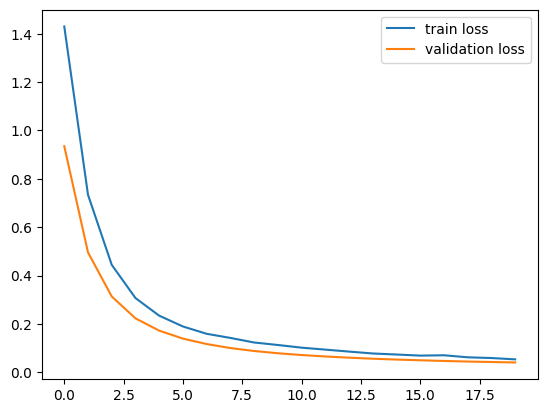

In [54]:
plt.plot(model_history.history['loss'],label='train loss')
plt.plot(model_history.history['val_loss'],label='validation loss')
plt.legend()
plt.show()

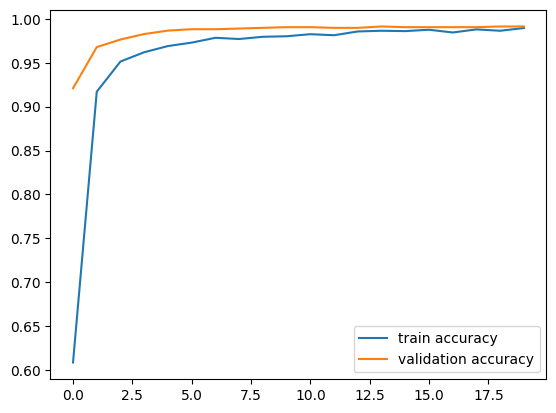

In [55]:
plt.plot(model_history.history['accuracy'],label='train accuracy')
plt.plot(model_history.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.show()

## Testing the model

In [57]:
import gradio as gr
import numpy as np
from PIL import Image

def predict_image(img_input):
    # 1. Preprocess the image to match EfficientNet's expected shape (224, 224, 3)
    img = Image.fromarray(img_input).resize((224, 224))
    img_array = np.asarray(img)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension

    # Get predictions for the single image (returns an array of decimals between 0.0 and 1.0)
    predictions = model.predict(img_array)[0]

    # Get class names from train_data
    class_names = train_data.class_names

    # Find the highest confidence decimal score
    highest_confidence = float(np.max(predictions))

    # Apply your hardcoded threshold check (0.50 = 50%)
    THRESHOLD = 0.50

    confidences = {class_names[i]: float(predictions[i]) for i in range(len(class_names))}

    # 5. Set your threshold (0.50 = 50%)
    THRESHOLD = 0.50

    if highest_confidence < THRESHOLD:
        # Give 'Other' a 1.0 score so it wins the top slot,
        # but keep the original vehicle dict intact underneath!
        confidences["Other"] = 1.0
    else:
        # If a vehicle is confidently detected, 'Other' has a 0% chance
        confidences["Other"] = 0.0

    return confidences

# Create the Gradio interface
# Note: We add +1 to num_top_classes just in case "Other" triggers
demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="numpy", label="Upload Vehicle Image"),
    outputs=gr.Label(num_top_classes=len(train_data.class_names) + 1),
    title="Vehicle Classification with EfficientNet",
    description="Upload an image. If the model's confidence is below 50%, it will categorize it as 'Other'."
)

# Launch the app locally or in your Kaggle notebook!
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bd6cb808a682254027.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
